In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargamos solo la primera tabla (filas 4 a 16)
df = pd.read_csv('ipc_capitulos.csv',
                 sep=';',
                 skiprows=4,
                 nrows=12,
                 decimal=',')

# Limpiamos
df = df.dropna(how='all')
df.columns = ['Capitulo'] + list(df.columns[1:])
df = df[df['Capitulo'].notna()]
df = df[df['Capitulo'].str.strip() != '']
df = df.set_index('Capitulo')

# Convertimos todo a numérico
df = df.apply(pd.to_numeric, errors='coerce')

print(df.shape)
print(df.head())

(10, 8)
                                        abr-16  may-16  jun-16  jul-16  \
Capitulo                                                                 
Nivel general                            100.0   104.2   107.4   109.6   
Alimentos y Bebidas                      100.0   103.7   107.0   109.9   
Indumentaria                             100.0   102.3   102.5   101.8   
Vivienda y servicios básicos             100.0   105.2   112.6   113.6   
Equipamiento y mantenimiento del hogar   100.0   102.9   107.7   110.3   

                                        ago-16  sept-16  oct-16  nov-16  
Capitulo                                                                 
Nivel general                            109.8    111.1   113.7   115.5  
Alimentos y Bebidas                      110.6    113.1   114.8   117.0  
Indumentaria                             102.6    107.6   111.4   112.8  
Vivienda y servicios básicos             107.2    101.5   112.4   114.0  
Equipamiento y mantenimiento 

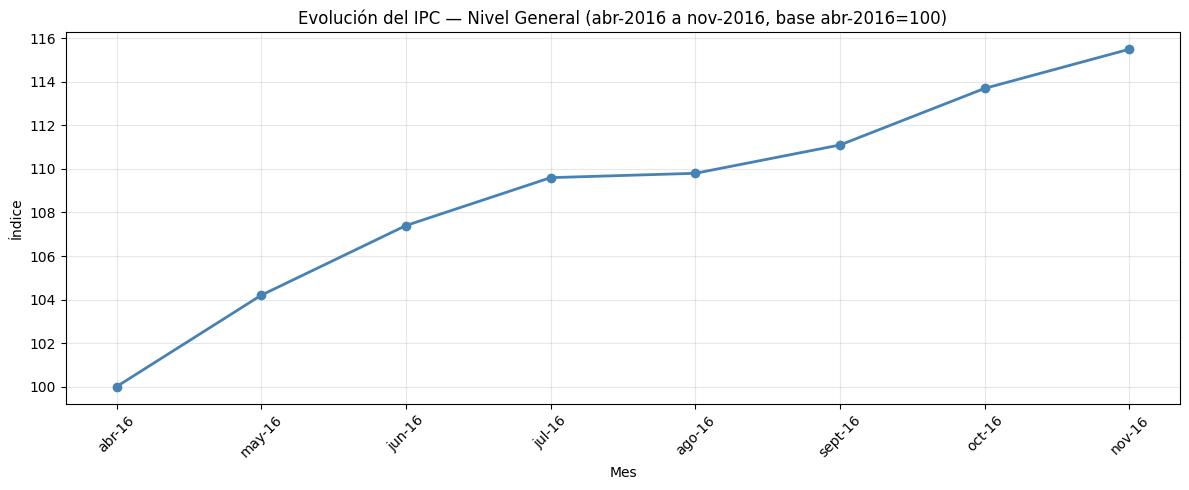

In [ ]:
# Análisis 1: Evolución del Nivel General IPC
nivel_general = df.loc['Nivel general']

plt.figure(figsize=(12,5))
plt.plot(nivel_general.index, nivel_general.values, marker='o', color='steelblue', linewidth=2)
plt.title('Evolución del IPC — Nivel General (abr-2016 a nov-2016, base abr-2016=100)')
plt.xlabel('Mes')
plt.ylabel('Índice')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

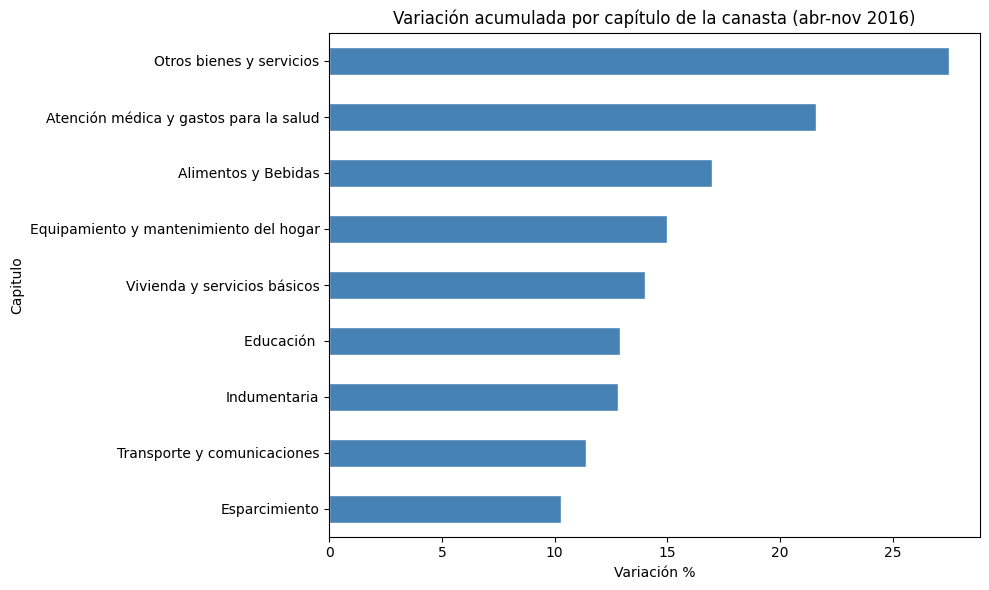

In [ ]:
# Análisis 2: Variación por capítulo — cuál subió más
variacion = ((df.iloc[:, -1] - df.iloc[:, 0]) / df.iloc[:, 0] * 100).sort_values(ascending=False)
variacion = variacion.drop('Nivel general')

variacion.plot(kind='barh', figsize=(10,6), color='steelblue', edgecolor='white')
plt.title('Variación acumulada por capítulo de la canasta (abr-nov 2016)')
plt.xlabel('Variación %')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

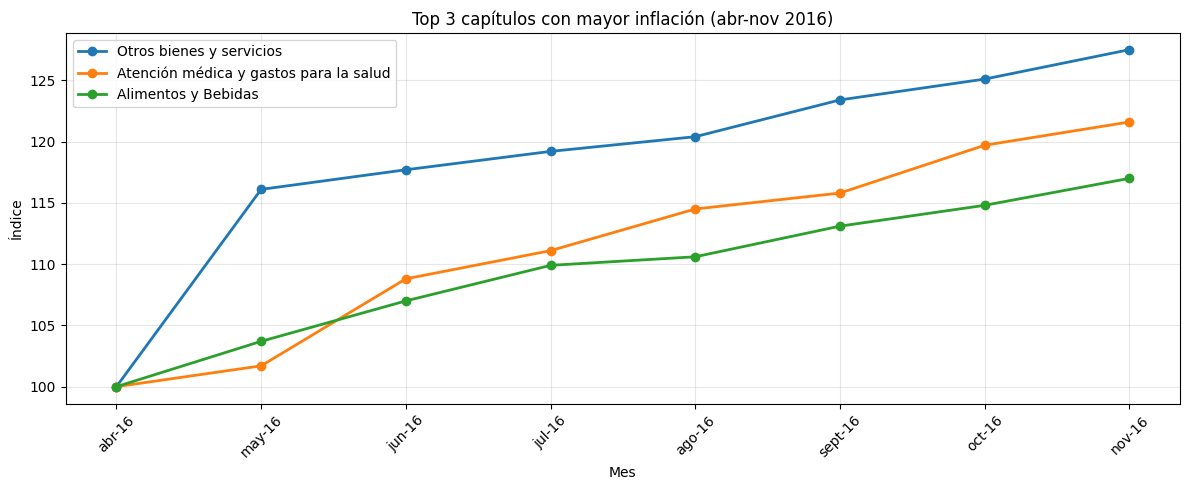

In [ ]:
# Análisis 3: Evolución de los 3 capítulos que más subieron
top3 = variacion.head(3).index.tolist()

plt.figure(figsize=(12,5))
for cap in top3:
    plt.plot(df.columns, df.loc[cap], marker='o', linewidth=2, label=cap)

plt.title('Top 3 capítulos con mayor inflación (abr-nov 2016)')
plt.xlabel('Mes')
plt.ylabel('Índice')
plt.legend()
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargamos el dataset completo 2017-2025
df_full = pd.read_csv('sh_ipc_11_25.csv',
                      sep=';',
                      skiprows=5,
                      nrows=13,
                      decimal=',',
                      header=0)

# Limpiamos
df_full = df_full.dropna(how='all')
df_full.columns = ['Division'] + list(df_full.columns[1:])
df_full = df_full[df_full['Division'].notna()]
df_full = df_full[df_full['Division'].str.strip() != '']
df_full = df_full.set_index('Division')
df_full = df_full.apply(pd.to_numeric, errors='coerce')

# Filtramos columnas por año
cols_2023 = [c for c in df_full.columns if '-23' in c]
cols_2025 = [c for c in df_full.columns if '-25' in c]

print("2023:", cols_2023)
print("2025:", cols_2025)
print(df_full.shape)

2023: ['ene-23', 'feb-23', 'mar-23', 'abr-23', 'may-23', 'jun-23', 'jul-23', 'ago-23', 'sept-23', 'oct-23', 'nov-23', 'dic-23']
2025: ['ene-25', 'feb-25', 'mar-25', 'abr-25', 'may-25', 'jun-25', 'jul-25', 'ago-25', 'sept-25', 'oct-25']
(11, 106)


In [2]:
# Análisis comparado: inflación acumulada anual por división
# 2023 vs 2025 (enero-octubre para comparar el mismo período)

# Acumulado 2023 completo
acum_2023 = ((1 + df_full[cols_2023] / 100).prod(axis=1) - 1) * 100

# Acumulado 2025 enero-octubre (mismo período que 2023 para comparar)
cols_2025_10 = [c for c in cols_2025 if c != 'nov-25']
acum_2025 = ((1 + df_full[cols_2025_10] / 100).prod(axis=1) - 1) * 100

# Armamos tabla comparativa
comparado = pd.DataFrame({
    '2023 (acum. anual)': acum_2023.round(1),
    '2025 (ene-oct)': acum_2025.round(1)
}).drop(index='Nivel general y divisiones COICOP', errors='ignore')

print(comparado.sort_values('2023 (acum. anual)', ascending=False))

                                                    2023 (acum. anual)  \
Division                                                                 
Alimentos y bebidas no alcohólicas                               251.2   
Equipamiento y mantenimiento del hogar                           232.2   
Salud                                                            227.5   
Recreación y cultura                                             218.3   
Nivel general                                                    211.2   
Transporte                                                       187.9   
Comunicación                                                     186.5   
Bebidas alcohólicas y tabaco                                     179.7   
Prendas de vestir y calzado                                      168.8   
Vivienda, agua, electricidad, gas y otros combu...               149.1   

                                                    2025 (ene-oct)  
Division                                  

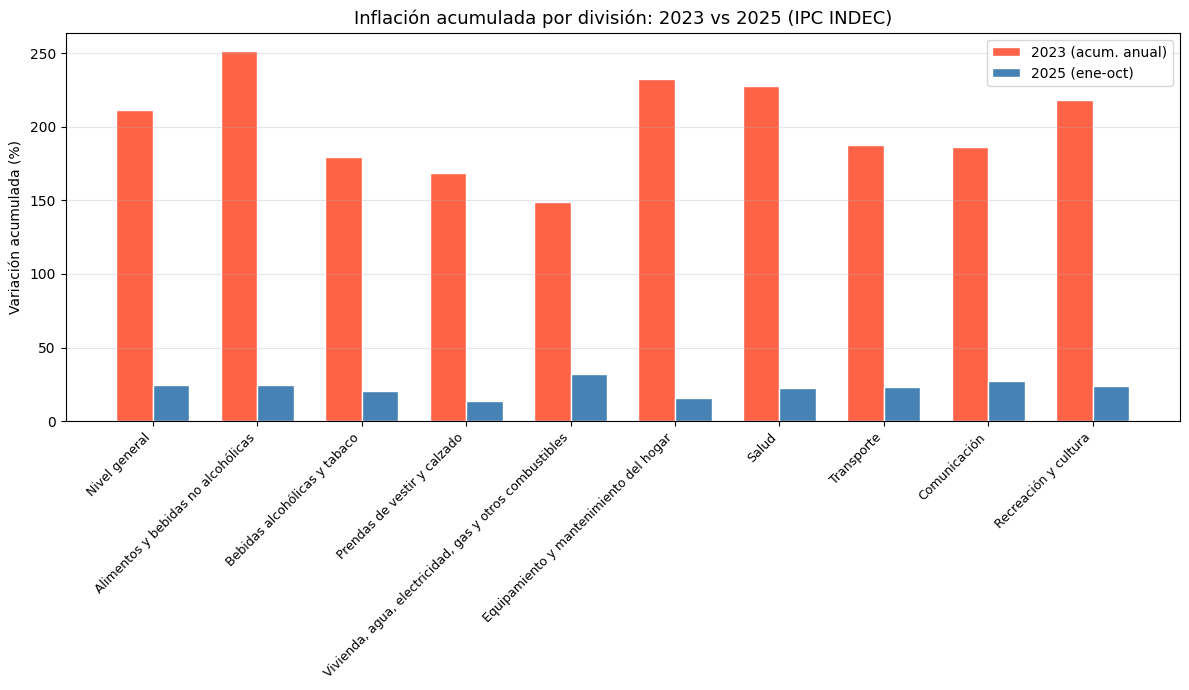

In [3]:
# Gráfico comparado 2023 vs 2025
fig, ax = plt.subplots(figsize=(12, 7))

x = range(len(comparado.index))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], comparado['2023 (acum. anual)'],
               width, label='2023 (acum. anual)', color='tomato', edgecolor='white')
bars2 = ax.bar([i + width/2 for i in x], comparado['2025 (ene-oct)'],
               width, label='2025 (ene-oct)', color='steelblue', edgecolor='white')

ax.set_title('Inflación acumulada por división: 2023 vs 2025 (IPC INDEC)', fontsize=13)
ax.set_ylabel('Variación acumulada (%)')
ax.set_xticks(list(x))
ax.set_xticklabels(comparado.index, rotation=45, ha='right', fontsize=9)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

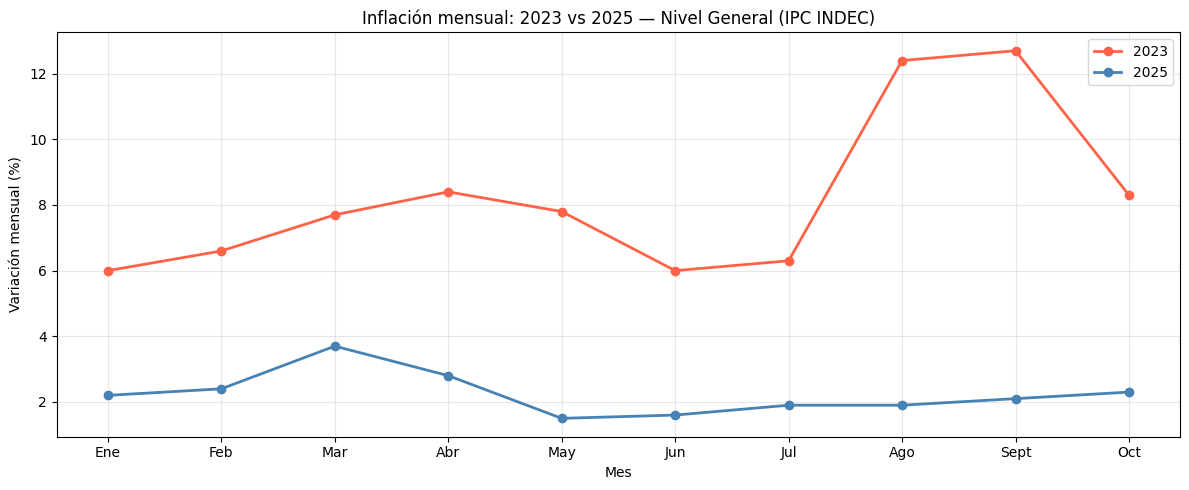

Promedio mensual 2023: 10.0 %
Promedio mensual 2025: 2.2 %


In [4]:
# Evolución mensual del Nivel General: 2023 vs 2025
nivel_2023 = df_full.loc['Nivel general', cols_2023]
nivel_2025 = df_full.loc['Nivel general', cols_2025]

meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sept', 'Oct']

plt.figure(figsize=(12, 5))
plt.plot(meses, nivel_2023.values[:10], marker='o', color='tomato',
         linewidth=2, label='2023')
plt.plot(meses, nivel_2025.values[:10], marker='o', color='steelblue',
         linewidth=2, label='2025')

plt.title('Inflación mensual: 2023 vs 2025 — Nivel General (IPC INDEC)')
plt.ylabel('Variación mensual (%)')
plt.xlabel('Mes')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Promedio mensual 2023:", round(nivel_2023.mean(), 1), "%")
print("Promedio mensual 2025:", round(nivel_2025.mean(), 1), "%")